## Alpha Model

### Move
Predict if price moves next step  
Driven by volatility, activity, liquidity  

### Direction
Predict direction given a move  
Driven by imbalance and order flow  

### Combine
p(up) = p(move) × p(up | move)

### Features
Grouped by type  
Select strongest within each group  
Reduce redundancy

## Move Model

Price moves are mainly driven by overall activity such as volatility, trade intensity, and liquidity.

### Method
- Use logistic regression with L1 to find important feature groups  
- Group features by type: volatility, trades, liquidity, imbalance  
- Within each group, use L2 to select strongest features  

- Focus on feature groups rather than individual variables  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from microstructure_alpha.data.loader import load_parquet_glob
from microstructure_alpha.features.feature_lists import (
    FINAL_FEATURES_WITH_TRANSFORM,
)

In [2]:
final_dataset = load_parquet_glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\ml_ready_data\\ml_ready.parquet",
    sort_by="timestamp",
)

In [3]:
target = "mid_price_moves"
final_dataset[target].value_counts(normalize=True)
len(final_dataset)

43999

### Data Splitting

- Use TimeSeriesSplit with rolling training window  
- Preserves time ordering  
- Allows model to adapt to changing market conditions

In [4]:
X = final_dataset[FINAL_FEATURES_WITH_TRANSFORM]
y = final_dataset[target]

In [5]:
from microstructure_alpha.models.train import run_model_parallel, run_fold
from microstructure_alpha.plots import plot_fold_aucs, plot_model_calibration
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

In [6]:
splits = 10
size_data = len(final_dataset)
tscv = TimeSeriesSplit(n_splits=splits, gap=50, max_train_size=int(size_data / splits))

### L1 Feature Selection

- Use L1 to remove weak and redundant features  
- Handles large number of correlated variables  
- Parallelised across folds for efficiency  

In [7]:
model = LogisticRegression(
    l1_ratio=1,
    solver="saga",
    C=1.0,
    max_iter=5000,
)

In [8]:
result = {}

result["rf"] = run_model_parallel(X, y, model, tscv, scale=True, n_jobs=8)
oof_preds =result["rf"]["fold_oof"]
fold_aucs = result["rf"]["fold_aucs"]
fold_coefs= result["rf"]["coefs"]

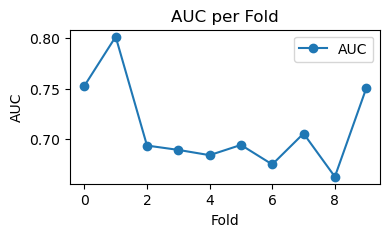

[0.7525676191025357, 0.8010456478679995, 0.6937708133943613, 0.6894893948362908, 0.6842929949115666, 0.6943850235276814, 0.6751631757124059, 0.705650729571113, 0.6630494029037213, 0.7500805692107644]


In [9]:
plot_fold_aucs(result["rf"]["fold_aucs"])
print(result["rf"]["fold_aucs"])

C:\Users\jayod\Documents\Quant_Project\microstructure-alpha-engine\microstructure_alpha\plots.py:154: RuntimeWarning: Mean of empty slice
  preds = np.nanmean(res["fold_oof"], axis=0)


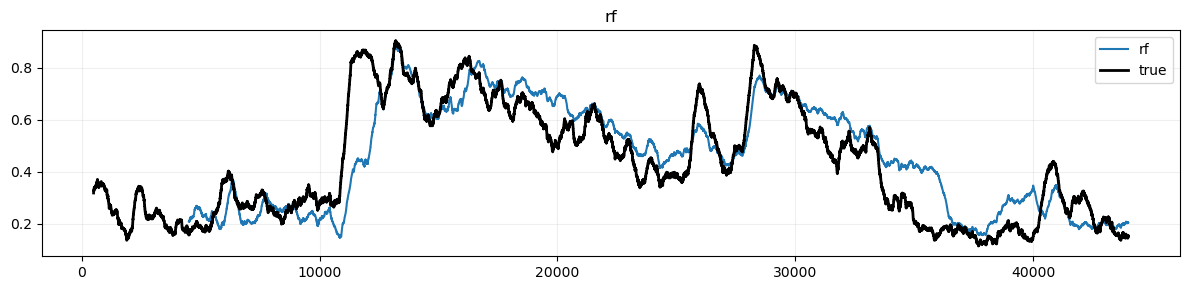

In [10]:
y_true = y.values
plot_model_calibration(result, y_true, window=500, show=True)

In [11]:
from microstructure_alpha.utils.io import save_tables

In [12]:
sorted_tables = []

for i in range(len(fold_coefs)):
    s = pd.Series(fold_coefs[i], index=FINAL_FEATURES_WITH_TRANSFORM)
    s = s.sort_values(key=abs, ascending=False)

    df_fold = pd.DataFrame({f"Fold_{i}_feature": s.index, f"Fold_{i}_coef": s.values})

    sorted_tables.append(df_fold.reset_index(drop=True))

save_tables(
    sorted_tables,
    save_dir="C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\notebooks\\saved_info\\l1_fold\\",
    file_name="fold_",
)

## Key Feature Families

Main drivers of price movement:

- Volatility  
- Trade intensity  
- Liquidity  
- Order book shape  
- Trade size  
- Order book imbalance  
- Trade flow imbalance  

### L2 Selection

- Train L2 within each group  
- Keep strongest features in each signal  

In [13]:
from microstructure_alpha.features.feature_lists import L2_FEATURE_LIST
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [14]:
model = LogisticRegression(
    l1_ratio=0,
    solver="lbfgs",
    C=1.0,
    max_iter=5000,
)

In [ ]:
coeffs_for_each_group = {}

for group in L2_FEATURE_LIST.keys():
    X = final_dataset[L2_FEATURE_LIST[group]]
    y = final_dataset[target]

    result = {}
    result = run_model_parallel(X, y, model, tscv, n_jobs=8)
    oof_preds = result["fold_oof"]
    fold_aucs = result["fold_aucs"]
    fold_coefs = result["coefs"]
    avg_abs = pd.Series(
        np.mean(np.abs(fold_coefs), axis=0), index=X.columns
    ).sort_values(ascending=False)

    coeffs_for_each_group[group] = avg_abs

In [16]:
import json

path = "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\notebooks\\saved_info\\l2_feature_select\\l2_feature_select.json"
out = {}

for k, v in coeffs_for_each_group.items():
    out[k] = v.to_dict()
with open(path, "w") as f:
    json.dump(out, f, indent=4)

# Final mid_price_move model vars

In [17]:
features = [
    # Vol
    "realized_vol_20_log1p",
    "realized_vol_5_log1p",
    # trade intensity
    "trade_count_log1p",
    "trade_count_change",
    # trade size
    "std_trade_size_log1p",
    "max_trade_size_log1p",
    "avg_trade_size_log1p",
    # liquidity
    "total_bid_volume_10_log1p",
    "total_book_volume_log1p",
    # volume_pressure
    "max_bid_ask_vol_ratio_log1p",
    # spread
    "rel_spread_log1p",
    # imbalance
    "imbalance_5",
    "imbalance_10",
    "imbalance_depth_3",
    # depth shape
    "lob_depth_ratio_4",
    "lob_depth_ratio_2",
    # trade_flow
    "sell_volume_log1p",
]